# 🧹 Paso 2 — Limpieza y Preprocesamiento
**Dataset:** Consumo eléctrico industrial
**Objetivo:** Limpiar, codificar y normalizar los datos para KNN y Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
sns.set_theme(style='whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar el dataset original (datos crudos)

In [2]:
ARCHIVO = r'd:\ExperimentoIAIA\data\raw\Steel_industry_data.csv'   

df = pd.read_csv(ARCHIVO)
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 35040 filas, 11 columnas


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## 2. Eliminar columna 'date' (no aporta como feature)

In [3]:
df = df.drop(columns=['date'])
print(f'Columna date eliminada. Columnas restantes: {list(df.columns)}')

Columna date eliminada. Columnas restantes: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


## 3. Verificar y manejar valores nulos

In [5]:
nulos = df.isnull().sum()
print(f'Total de valores nulos: {nulos.sum()}')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Sin valores nulos')

# Numéricas: rellenar con mediana
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categóricas: rellenar con moda
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Valores nulos después del tratamiento: {df.isnull().sum().sum()}')

Total de valores nulos: 0
✅ Sin valores nulos
Valores nulos después del tratamiento: 0


C:\Users\ACER\AppData\Local\Temp\ipykernel_22776\1882595294.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


## 4. Verificar y eliminar duplicados

In [6]:
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplicados eliminados. Filas restantes: {len(df)}')
else:
    print('✅ Sin duplicados')

Filas duplicadas: 81
✅ Duplicados eliminados. Filas restantes: 34959


## 5. Codificar variables categóricas
`WeekStatus`, `Day_of_week` y `Load_Type` son texto y deben convertirse a números.

In [7]:
le = LabelEncoder()

# WeekStatus: Weekday / Weekend → 0 / 1
df['WeekStatus'] = le.fit_transform(df['WeekStatus'])
print(f'WeekStatus codificado: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Day_of_week: lunes=0 ... domingo=6
df['Day_of_week'] = le.fit_transform(df['Day_of_week'])
print(f'Day_of_week codificado: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Load_Type (objetivo): Light=0, Maximum=1, Medium=2
df['Load_Type'] = le.fit_transform(df['Load_Type'])
clases_load = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Load_Type codificado: {clases_load}')

df.head()

WeekStatus codificado: {'Weekday': np.int64(0), 'Weekend': np.int64(1)}
Day_of_week codificado: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}
Load_Type codificado: {'Light_Load': np.int64(0), 'Maximum_Load': np.int64(1), 'Medium_Load': np.int64(2)}


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,0,1,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,0,1,0


## 6. Separar features (X) y variable objetivo (y)

In [8]:
X = df.drop('Load_Type', axis=1)
y = df['Load_Type']

print(f'Features (X): {X.shape}  →  {list(X.columns)}')
print(f'Objetivo  (y): {y.shape}')
print(f'Clases: {y.unique()}')

Features (X): (34959, 9)  →  ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week']
Objetivo  (y): (34959,)
Clases: [0 2 1]


## 7. Normalización con StandardScaler

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('ANTES de normalizar (media / desviación estándar):')
print(X.describe().loc[['mean','std']].round(3))
print('\nDESPUÉS de normalizar:')
print(X_scaled.describe().loc[['mean','std']].round(3))

ANTES de normalizar (media / desviación estándar):
      Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
mean     27.443                                13.056   
std      33.463                                16.319   

      Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
mean                                 3.876      0.012   
std                                  7.428      0.016   

      Lagging_Current_Power_Factor  Leading_Current_Power_Factor        NSM  \
mean                        80.625                        84.350  42781.344   
std                         18.903                        30.468  24923.195   

      WeekStatus  Day_of_week  
mean       0.284        2.995  
std        0.451        2.001  

DESPUÉS de normalizar:
      Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
mean       -0.0                                   0.0   
std         1.0                                   1.0   

      Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
mean              

## 8. Visualización antes/después de normalizar

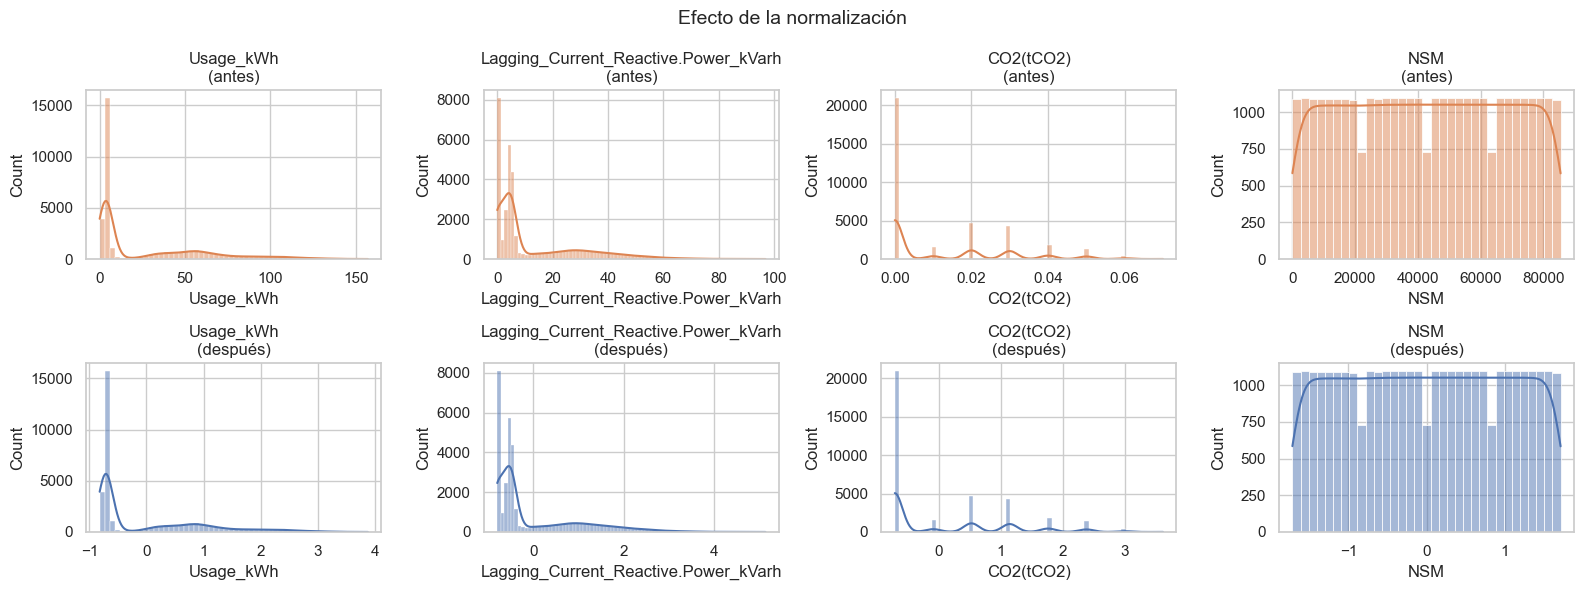

In [10]:
cols_muestra = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
                'CO2(tCO2)', 'NSM']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, col in enumerate(cols_muestra):
    sns.histplot(X[col], kde=True, ax=axes[0][i], color='#DD8452')
    axes[0][i].set_title(f'{col}\n(antes)')
    sns.histplot(X_scaled[col], kde=True, ax=axes[1][i], color='#4C72B0')
    axes[1][i].set_title(f'{col}\n(después)')

plt.suptitle('Efecto de la normalización', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/figures/normalizacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. División Train / Test (80% / 20%)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Prueba:        {X_test.shape[0]} filas ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'\nDistribución en train:\n{y_train.value_counts()}')
print(f'\nDistribución en test:\n{y_test.value_counts()}')

Entrenamiento: 27967 filas (80%)
Prueba:        6992 filas (20%)

Distribución en train:
Load_Type
0    14395
2     7754
1     5818
Name: count, dtype: int64

Distribución en test:
Load_Type
0    3599
2    1939
1    1454
Name: count, dtype: int64


## 10. Guardar datos procesados

In [12]:
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print('✅ Archivos guardados en data/processed/')
print('   · X_train.csv  →', X_train.shape)
print('   · X_test.csv   →', X_test.shape)
print('   · y_train.csv  →', y_train.shape)
print('   · y_test.csv   →', y_test.shape)
print('\n✅ Preprocesamiento completado. Continúa con 03_knn.ipynb')

✅ Archivos guardados en data/processed/
   · X_train.csv  → (27967, 9)
   · X_test.csv   → (6992, 9)
   · y_train.csv  → (27967,)
   · y_test.csv   → (6992,)

✅ Preprocesamiento completado. Continúa con 03_knn.ipynb
